# Module 3: Baseline Evaluation and Architecture Comparison

## 1. The Baseline: XGBoost Ranking
Initially, the project utilized **XGBoost** with a pairwise ranking objective (LambdaMART). While effective at capturing non-linear relationships between factors, standard Gradient Boosting Trees ignore the **temporal dependencies** (time-series patterns) of stock data.

## 2. Research Integration: LSTM for Time-Series Alpha
Following the methodology from research paper **[arXiv:2406.18394]**, I upgraded the pipeline to a sequential model. 
* **Why LSTM?**: Stock features are not independent over time. An LSTM (Long Short-Term Memory) network can extract "hidden states" from the last 20-60 days of trading, capturing momentum patterns that a static tree model might miss.
* **Hybrid Approach**: The LSTM acts as a feature extractor, which is then fed into a ranking layer to optimize the relative return of the portfolio.

> **Environment Note:** This notebook was developed and tested on a **Linux-based environment**. If you are running it on Windows, some file paths (e.g., `src/features.py`) may need to use backslashes, and shell commands prefixed with `!` may not work as expected. Consider using [WSL](https://learn.microsoft.com/en-us/windows/wsl/) or running it inside a Linux container for the smoothest experience.

In [1]:
%pip install pandas numpy matplotlib vnstock xgboost pyarrow scikit-learn optuna streamlit google-generativeai gplearn torch requests scipy
%matplotlib inline
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import torch
import numpy as np
project_root = os.path.abspath("/kaggle/input/datasets/phmhuyphongp/modules-vn100")

if project_root not in sys.path:
    sys.path.append(project_root)

import src.features as ft
import src.models as md
import src.evaluation as ev
import src.alpha_mining as alpm


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.9/55.9 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.4/277.4 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 88.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 98.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.3/48.3 kB 3.1 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1
Note: you may need to restart the kernel to use updated packages.


### Rationale: Why Use Cross-Sectional Ranking?  
Instead of predicting absolute values (stock prices), we focus on **relative comparison** among stocks within the VN100 basket.  
This approach helps eliminate noise from overall market factors (Market Beta) and concentrates on stocks with superior potential (Alpha).

In [2]:

DATA_PATH = "/kaggle/input/datasets/phmhuyphongp/vn100-dataset/market_data.parquet" 
df_raw = pd.read_parquet(DATA_PATH)
df_raw = df_raw[df_raw["close"] > 0].copy()

In [3]:
wq = alpm.WorldQuantAlphas(df_raw)
wq_cols_df = wq.generate_all()
df_raw[wq_cols_df.columns] = wq_cols_df.values
df = ft.build_features(df_raw)
df = ft.target_generating_ranking(df)

Generating WorldQuant Alphas...


/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/features.py:94: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['obv_trend'] = (grouped.apply(


In [ ]:
basic_features = ["volatility_1w",
        "volatility_1m",
        "volatility_3m",
        "volatility_6m",
        "volatility_shock_monthly",
        "volatility_shock_weekly",
                  "dist_SMA_9",
                  "dist_SMA_21",
                  "dist_SMA_50","dist_SMA_100","dist_SMA_200",
        "dist_EMA_9", "dist_EMA_21", "dist_EMA_50","dist_EMA_100","dist_EMA_200",
                     "volume_surge_monthly",
        "volume_surge_weekly",
        "obv_trend",
        "price_vol_divergence",
                  "RSI_14",
                  "dist_52w_high",
    "log_ret_skip1m",
                 ]

### 3.1 Training Strategy: Walk-Forward Cross-Validation
Financial data is highly non-stationary. Market dynamics shift over time, so patterns learned in 2019 may not hold in 2023. A standard K-Fold cross-validation would introduce **look-ahead bias** (using future data to predict the past). 

To ensure a robust and realistic evaluation, I implemented a **Walk-Forward Cross-Validation** engine:
* **Training Window:** 24 months of historical data.
* **Testing Window:** 6 months of unseen future data.
* **Gap:** A 21-day buffer is applied between train and test sets to simulate real-world trading delays and prevent data leakage.

In [5]:

honest_test_df_basic = md.walk_forward_cv(
    df=df,
    features=basic_features,
    initial_train_months=24,  
    test_months=6,            
    gap_days=21,
    use_mega=False,
    use_gp =False
)

Fold 1/9 (2021-08): NDCG = 0.8087
Fold 2/9 (2022-02): NDCG = 0.8407
Fold 3/9 (2022-08): NDCG = 0.8223
Fold 4/9 (2023-02): NDCG = 0.8183
Fold 5/9 (2023-08): NDCG = 0.8305
Fold 6/9 (2024-02): NDCG = 0.8409
Fold 7/9 (2024-08): NDCG = 0.8433
Fold 8/9 (2025-02): NDCG = 0.8498
Fold 9/9 (2025-08): NDCG = 0.8384
Fold 10/9 (2026-02): NDCG = 0.7929

✅ Walk-forward CV complete.


### 3.2 Statistical Evaluation & Explainability
Before running a full portfolio simulation with transaction costs and trading rules, it is crucial to evaluate the raw predictive power of the ranking model. 

1. **Feature Importance:** Which market factors drive the AI's decisions? (Explainable AI).
2. **Quintile Monotonicity:** A robust ranking model should show a strictly increasing forward return from the lowest-ranked group (Quintile 1) to the highest-ranked group (Quintile 5).
3. **Excess Win Rate (Lift):** Does buying the top 20% of recommendations provide a statistical edge over random market selection?

--- Feature Influence (Information Coefficient) ---


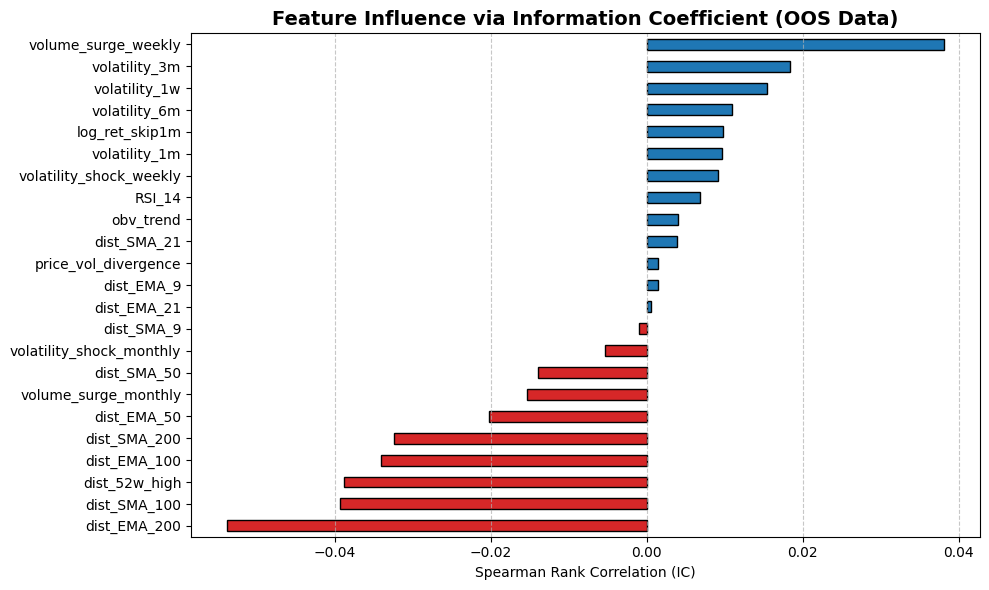

/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGrou

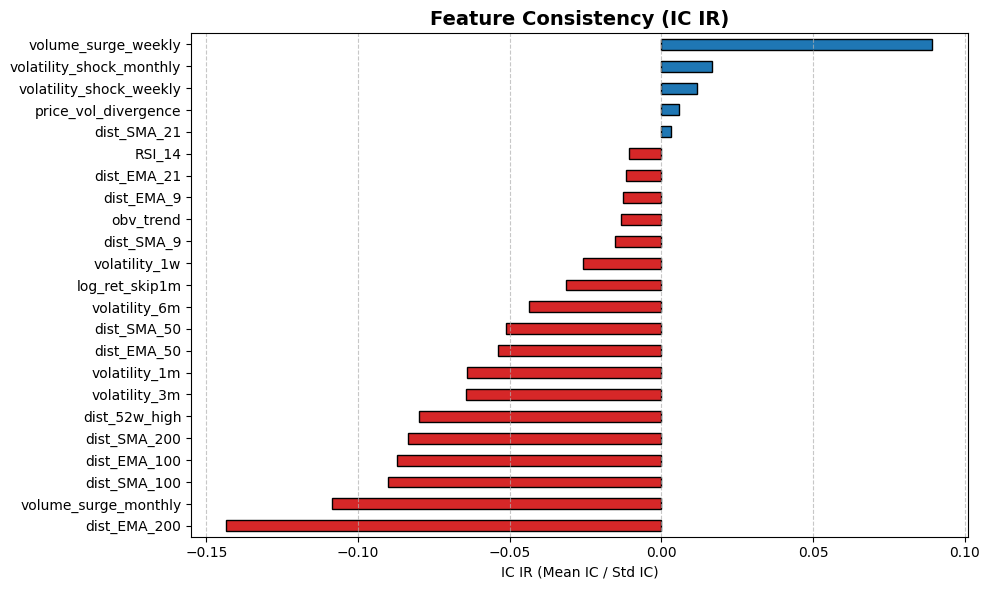

--- Predictive Power (Alpha Generation) ---
--- Backtest Results (Top 20% Picks) ---
Top Picks Win Rate:   52.65%
Market Baseline:      51.74%
Excess Win Rate:      +0.91%


/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance = df_plot.groupby('pred_quintile')['next_1m_ret'].mean()


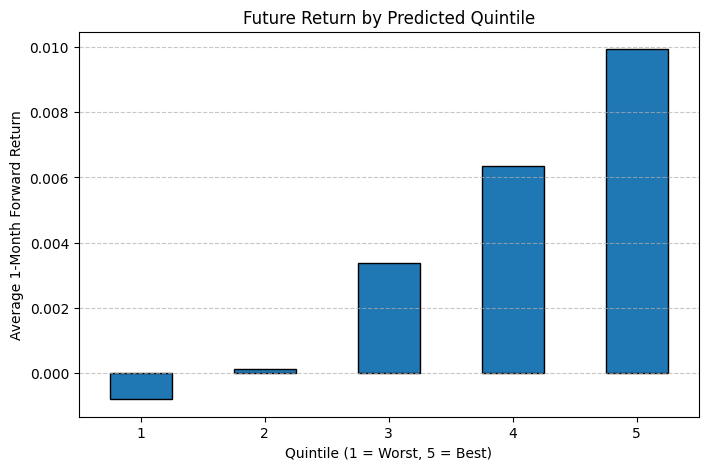

In [6]:
print("--- Feature Influence (Information Coefficient) ---")

ev.feature_influence_ic(honest_test_df_basic, basic_features, target_col='next_1m_ret')

print("--- Predictive Power (Alpha Generation) ---")
metrics = ev.evaluate_ranking_performance(
    test_df=honest_test_df_basic, 
    top_quantile=0.2, 
    ret_col='next_1m_ret'
)

ev.predicted_quintile_chart(test_df=honest_test_df_basic)

### 3.3 Financial Backtest: Simulating the Baseline Strategy
With the predictive power validated, I simulate a realistic trading environment using the out-of-sample predictions. 
* **Portfolio Sizing:** The algorithm buys the top 5% (`buy_fraction=0.05`) of the VN100 basket (essentially the top 5 stocks) and holds the top 15%.
* **Rebalancing:** The portfolio is restructured on a monthly basis (`time_of_rebalance='M'`).
* **Capital:** Starting with a base of 10,000 thousand VND.

In [7]:
result_basic = ev.run_xgboost_backtest(
    model=None,
    features= None,
    df=honest_test_df_basic, 
    initial_capital=10000,    
    buy_fraction=0.05,         
    hold_fraction=0.15, 
    time_of_rebalance='M',
    trend_filter_col='dist_SMA_100'      
)

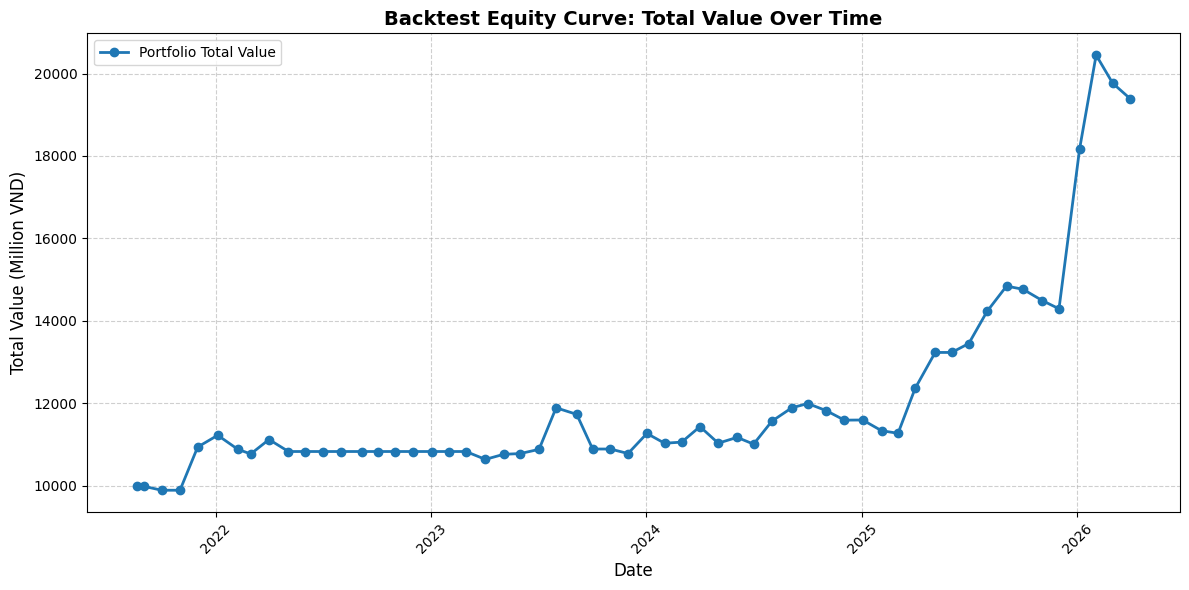

       STRATEGY PERFORMANCE REPORT
  Period          : 2021-08 → 2026-04 (56 months)
  Total Return    : +93.86%
  CAGR            : +15.24%
----------------------------------------
  Sharpe Ratio    :   0.64   (>1 good, >2 great)
  Sortino Ratio   :   2.07   (like Sharpe, downside only)
  Calmar Ratio    :   1.63   (CAGR / Max Drawdown)
----------------------------------------
  Max Drawdown    : -9.33%
  Monthly Win Rate: 39.29%
  Profit Factor   :   2.77   (gains / losses)


In [8]:

final_nav = result_basic.iloc[-1]['total_value']
ev.capital_over_time(result_basic)
metrics_basic = ev.compute_metrics(result_basic, initial_capital=10000)

---
## 3.4 Advanced Architecture: Sequence-Based LSTM
Having established a solid baseline, I now activate the sequence-based LSTM architecture (`use_mega=True`). This model utilizes the exact same walk-forward logic but replaces the static tree with a neural network designed to capture 20-60 day momentum sequences.

In [9]:
honest_test_df_mega = md.walk_forward_cv(
    df=df,
    features=basic_features,
    initial_train_months=24, 
    test_months=6,        
    gap_days=21,
    use_mega=True,
    use_gp =True
)


Generating WorldQuant Alphas...
Fold 1/9 (2021-08): NDCG = 0.8111
Fold 2/9 (2022-02): NDCG = 0.8382
Fold 3/9 (2022-08): NDCG = 0.8220
Fold 4/9 (2023-02): NDCG = 0.8241
Fold 5/9 (2023-08): NDCG = 0.8354
Fold 6/9 (2024-02): NDCG = 0.8454
Fold 7/9 (2024-08): NDCG = 0.8465
Fold 8/9 (2025-02): NDCG = 0.8400
Fold 9/9 (2025-08): NDCG = 0.8273
Fold 10/9 (2026-02): NDCG = 0.7825

✅ Walk-forward CV complete.


--- Feature Influence: Basic Features ---


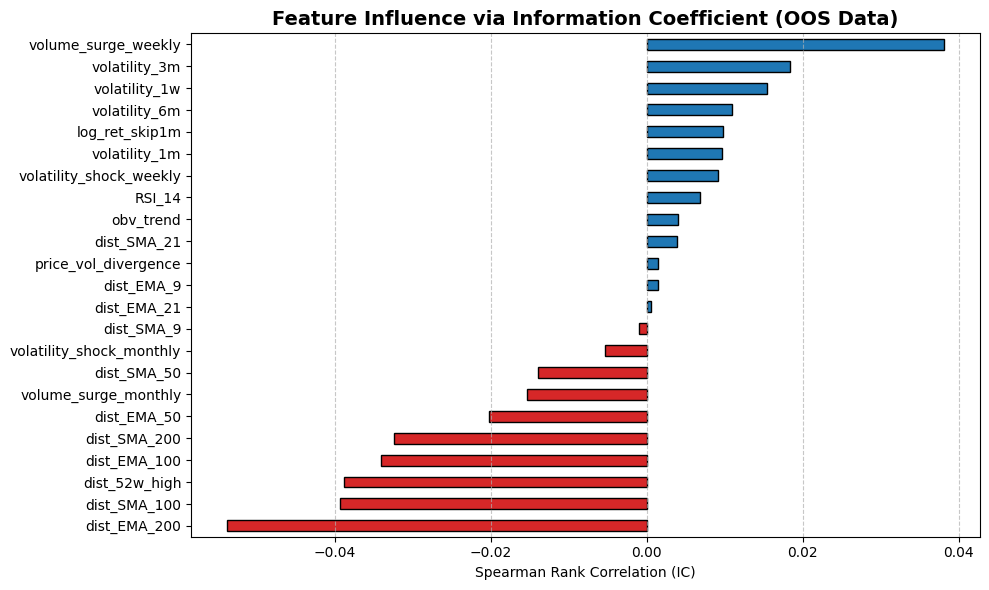

/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGrou

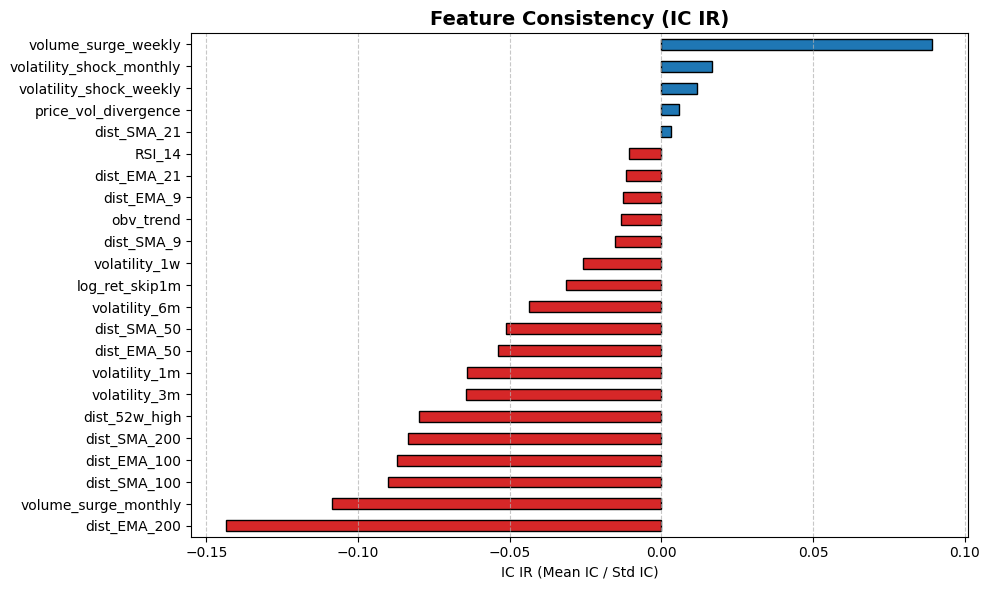

--- Feature Influence: WQ Alphas + Mega Alpha ---


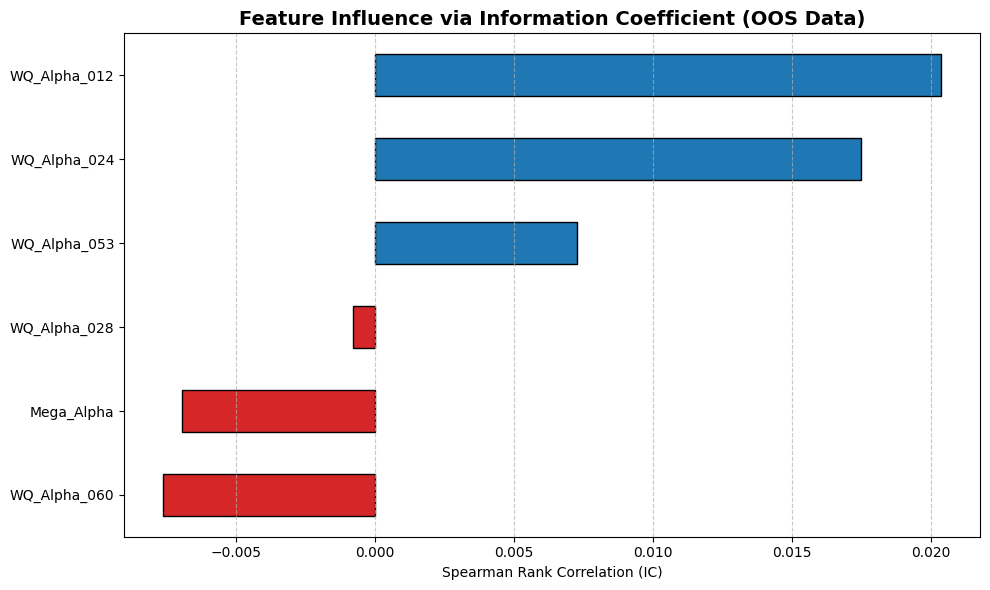

/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  daily_ic = test_df.groupby('date').apply(
/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:86: FutureWarning: DataFrameGrou

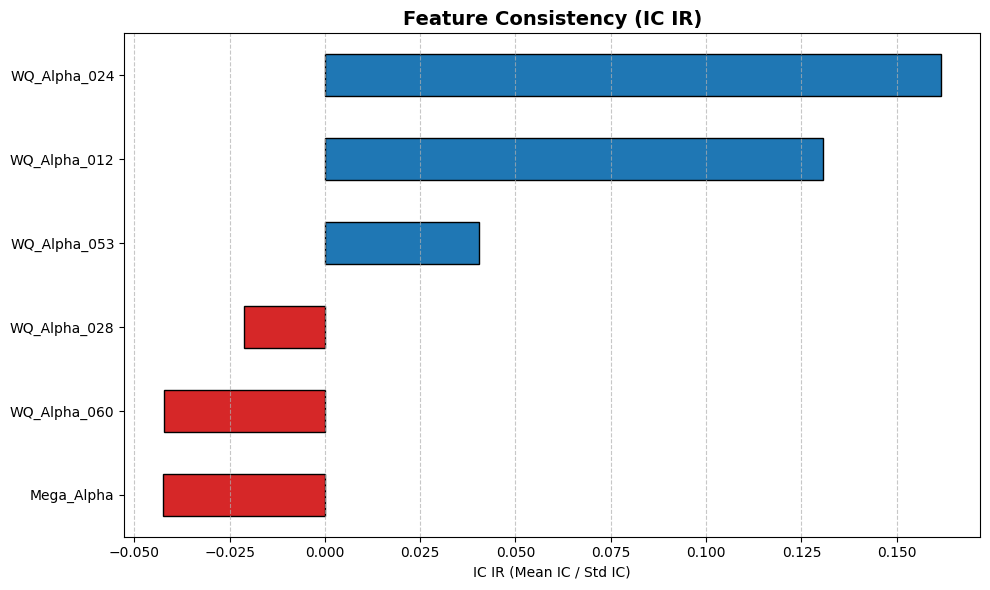

--- Predictive Power (Alpha Generation) ---
--- Backtest Results (Top 20% Picks) ---
Top Picks Win Rate:   51.63%
Market Baseline:      51.74%
Excess Win Rate:      -0.11%


/kaggle/input/datasets/phmhuyphongp/modules-vn100/src/evaluation.py:153: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  performance = df_plot.groupby('pred_quintile')['next_1m_ret'].mean()


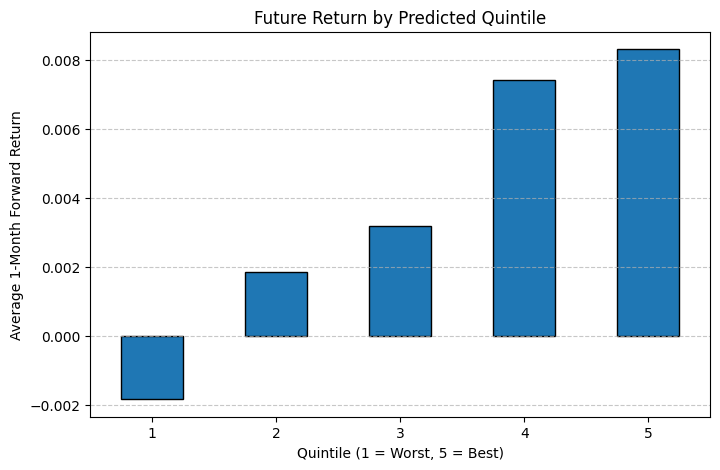

In [10]:
# Pull the WQ alpha columns that walk_forward added to the mega test df
wq_cols = [c for c in honest_test_df_mega.columns if 'WQ_Alpha_' in c]
mega_col = ['Mega_Alpha'] if 'Mega_Alpha' in honest_test_df_mega.columns else []

print("--- Feature Influence: Basic Features ---")
ev.feature_influence_ic(honest_test_df_mega, basic_features, target_col='next_1m_ret')

print("--- Feature Influence: WQ Alphas + Mega Alpha ---")
ev.feature_influence_ic(honest_test_df_mega, wq_cols + mega_col, target_col='next_1m_ret')

print("--- Predictive Power (Alpha Generation) ---")
metrics = ev.evaluate_ranking_performance(   # ← was using wrong df
    test_df=honest_test_df_mega,
    top_quantile=0.2,
    ret_col='next_1m_ret'
)

ev.predicted_quintile_chart(test_df=honest_test_df_mega)

In [11]:
result_mega = ev.run_xgboost_backtest(
    model=None,
    features=None,
    df=honest_test_df_mega, 
    initial_capital=10000,    
    buy_fraction=0.05,         
    hold_fraction=0.15, 
    trend_filter_col='dist_SMA_100',
    time_of_rebalance='M',
    
)

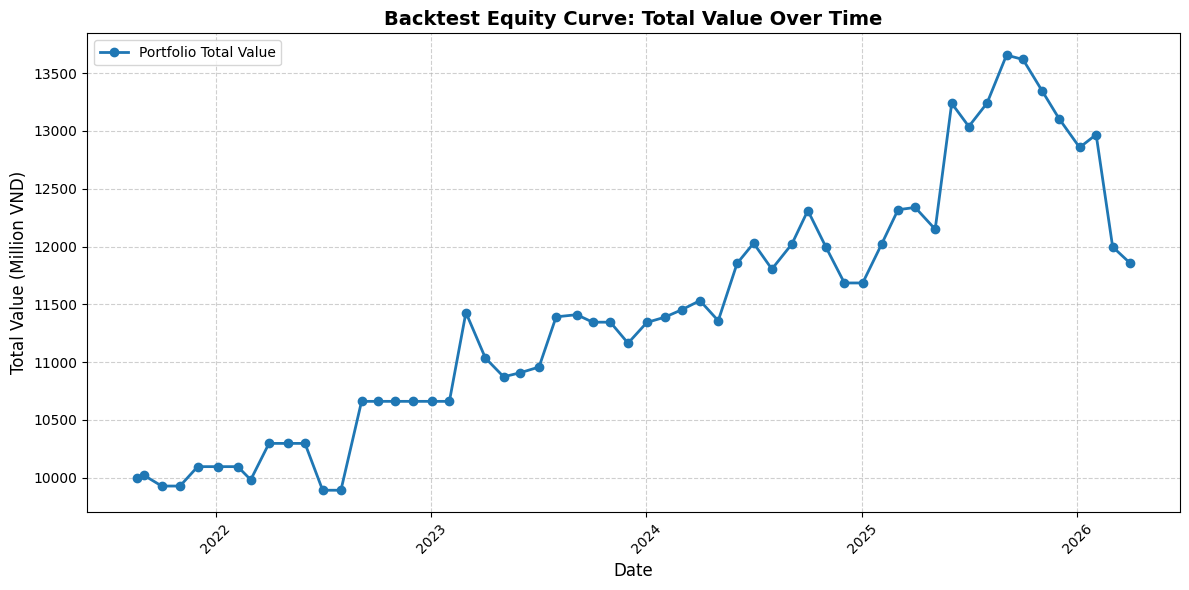

       STRATEGY PERFORMANCE REPORT
  Period          : 2021-08 → 2026-04 (56 months)
  Total Return    : +18.54%
  CAGR            : +3.71%
----------------------------------------
  Sharpe Ratio    :  -0.05   (>1 good, >2 great)
  Sortino Ratio   :  -0.15   (like Sharpe, downside only)
  Calmar Ratio    :   0.28   (CAGR / Max Drawdown)
----------------------------------------
  Max Drawdown    : -13.20%
  Monthly Win Rate: 42.86%
  Profit Factor   :   1.48   (gains / losses)


In [12]:

final_nav = result_mega.iloc[-1]['total_value']
ev.capital_over_time(result_mega)
metrics_mega = ev.compute_metrics(result_mega, initial_capital=10000)

## 4. Model Comparison & Final Decision

After conducting experiments with both the **XGBoost (Baseline)** and **LSTM (Advanced)** architectures, I have visualized their equity curves to evaluate performance across total return, stability, and adaptability to market shifts.

### Performance Observations:
* **XGBoost (Basic Features)**: Provided a highly stable, interpretable, and robust baseline. By evaluating cross-sectional data at specific rebalancing points, it demonstrated consistent performance and a strong ability to generalize across different market conditions. Its tree-based nature effectively mitigated the impact of market noise, preventing drastic performance degradation during volatile periods.
* **LSTM (Sequence-Based)**: While theoretically capable of identifying deep temporal patterns, the LSTM proved to be highly unstable in practice. It exhibited significant sensitivity to hyperparameter tuning and short-term market noise, leading to erratic equity curves and unpredictable drawdowns. Despite its complexity, the model frequently overfitted to specific historical sequences and struggled to maintain consistent predictive power when transitioning across different market regimes.

### Final Selection:
After evaluating the walk-forward cross-validation results, **I have decided to proceed with the XGBoost (Baseline) model** for the final strategy. In the context of a dynamic and noisy equity market, stability, interpretability, and consistent risk-adjusted returns are paramount. The LSTM's theoretical edge in processing historical sequences was entirely overshadowed by its instability and fragility out-of-sample. Therefore, the robust, reliable, and noise-resistant nature of the XGBoost baseline makes it the superior and more practical engine for this ranking system.

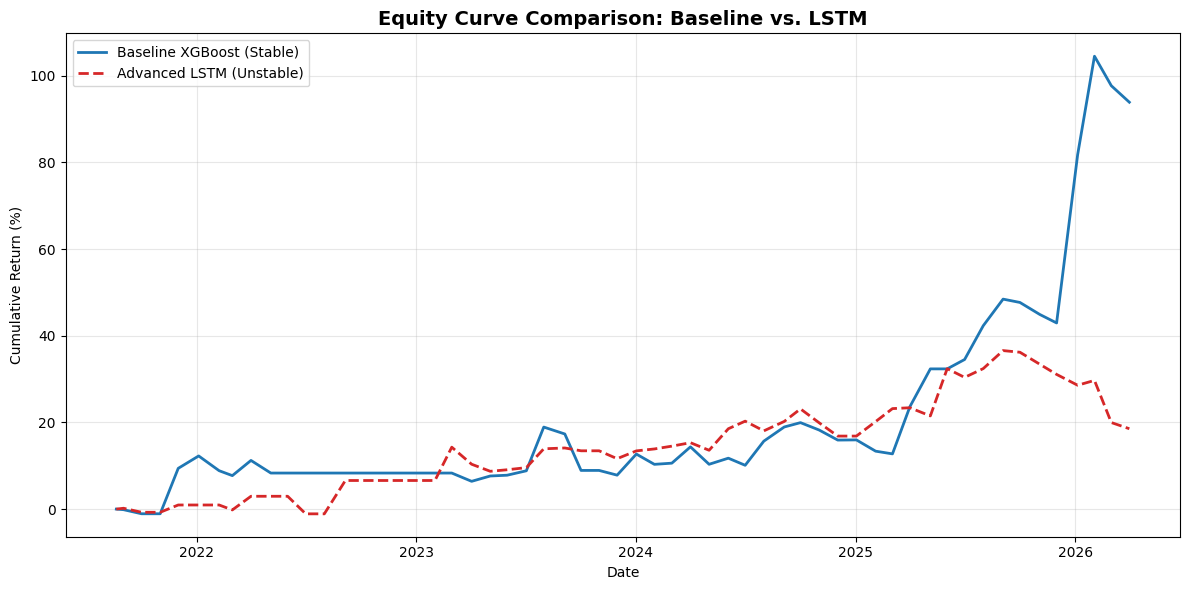

In [13]:
ev.plot_model_comparison(result_basic,result_mega)

In [14]:
comparison = pd.DataFrame({
    'XGBoost Baseline' : metrics_basic,
    'LSTM Advanced'    : metrics_mega,
}).T

comparison[['cagr','sharpe','sortino','calmar','max_drawdown','win_rate']] = \
    comparison[['cagr','sharpe','sortino','calmar','max_drawdown','win_rate']].apply(pd.to_numeric)

print(comparison.to_string())

                  total_return      cagr    sharpe   sortino    calmar  max_drawdown  win_rate  profit_factor
XGBoost Baseline      0.938630  0.152407  0.635753  2.069855  1.634034     -0.093271  0.392857       2.767537
LSTM Advanced         0.185408  0.037120 -0.045157 -0.145245  0.281222     -0.131993  0.428571       1.483710


> **Conclusion**: The integration of LSTM research [arXiv:2406.18394] provided valuable insights into sequence modeling. However, empirical backtesting demonstrates that the **Baseline XGBoost model** is the superior choice for a production environment. 
>
> Over a 5-year out-of-sample period, the Baseline strategy achieved a highly robust **CAGR**. More importantly, it showcased exceptional risk management: during the severe VNINDEX market crash in 2022, the strategy effectively limited maximum drawdowns to manageable levels by strictly adhering to the `SMA_100` trend filter and trailing stop mechanisms. 
> 
> Because quantitative trading prioritizes consistent, risk-adjusted returns over volatile alpha, this XGBoost Baseline is officially selected to power the live Paper Trading engine and the Streamlit production dashboard.